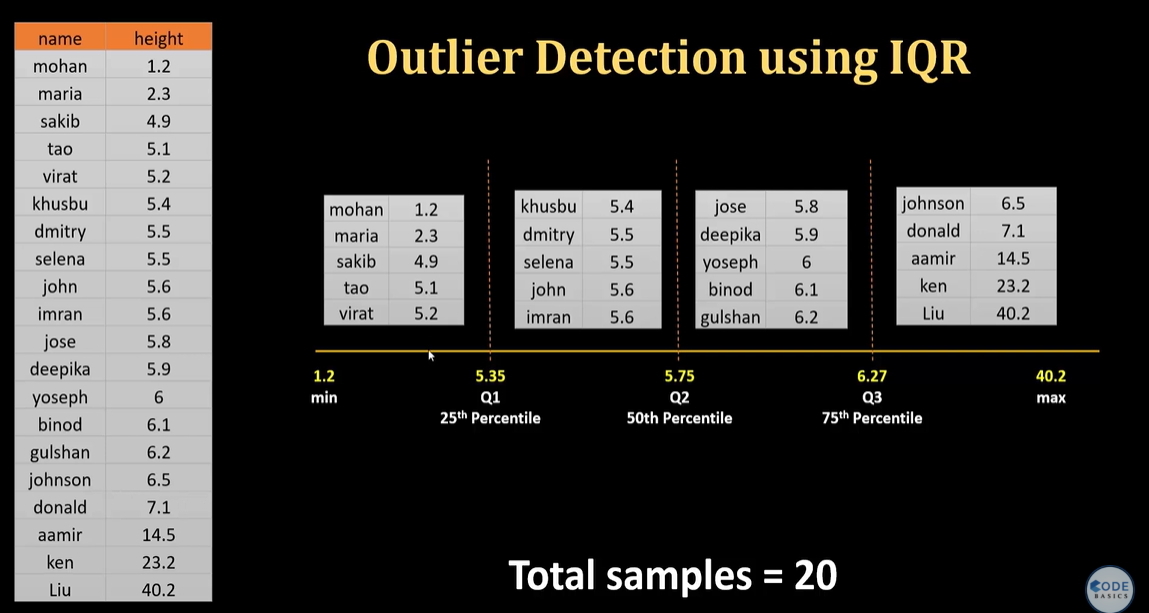
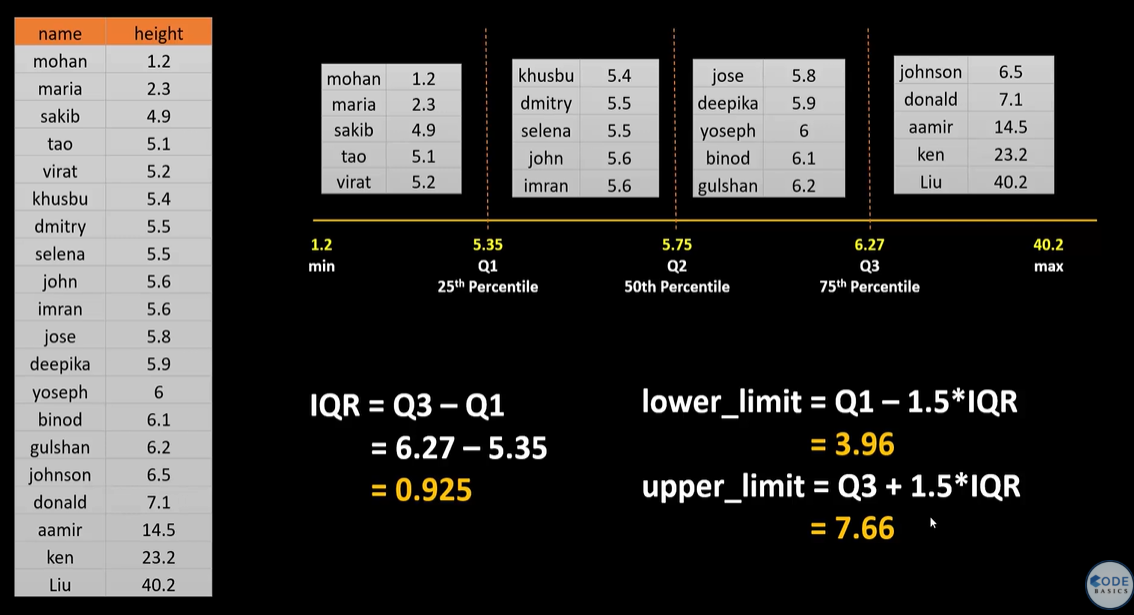
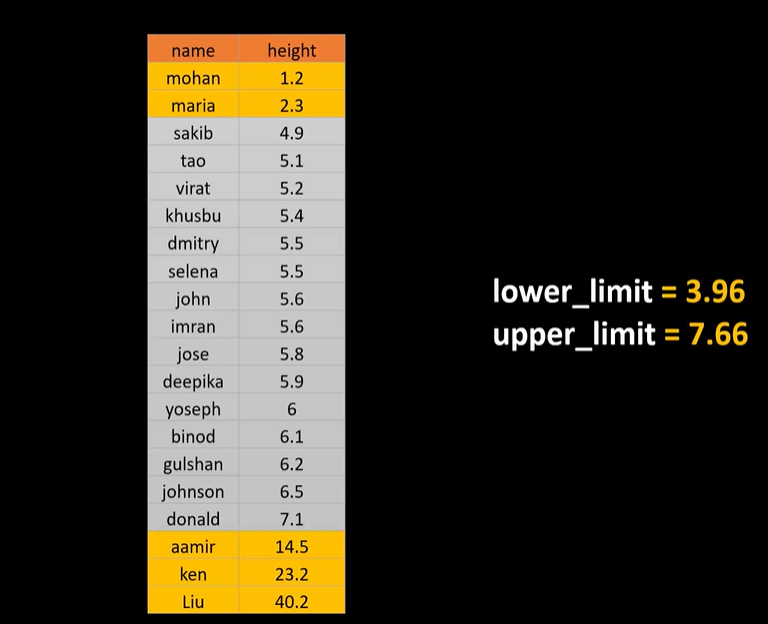

Outlier Detection and Removal Using IQR

In [3]:
import pandas as pd
df = pd.read_csv("heightsIQR.csv")
df

,name,height
0,mohan,1.2
1,maria,2.3
2,sakib,4.9
3,tao,5.1
4,virat,5.2
5,khusbu,5.4
6,dmitry,5.5
7,selena,5.5
8,john,5.6
9,imran,5.6


In [4]:
df.describe()

,height
count,20.000000
mean,8.390000
std,8.782812
min,1.200000
25%,5.350000
50%,5.700000
75%,6.275000
max,40.200000


Detect outliers using IQR

In [5]:
Q1 = df.height.quantile(0.25)
Q3 = df.height.quantile(0.75)
Q1, Q3

(5.3500000000000005, 6.275)

In [6]:
IQR = Q3 - Q1
IQR

0.9249999999999998

In [7]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(3.962500000000001, 7.6625)

In [8]:
# Detect outliers using IQR
df[(df.height<lower_limit) | (df.height>upper_limit)]

,name,height
0,mohan,1.2
1,maria,2.3
17,aamir,14.5
18,ken,23.2
19,Liu,40.2


In [9]:
# Remove outliers
df_no_outlier = df[(df.height>lower_limit)&(df.height<upper_limit)]
df_no_outlier

,name,height
2,sakib,4.9
3,tao,5.1
4,virat,5.2
5,khusbu,5.4
6,dmitry,5.5
7,selena,5.5
8,john,5.6
9,imran,5.6
10,jose,5.8
11,deepika,5.9


Exercise

In [14]:
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
df = pd.read_csv("height_weight.csv")
df.head()

,gender,height,weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [15]:
df.describe()

,height,weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


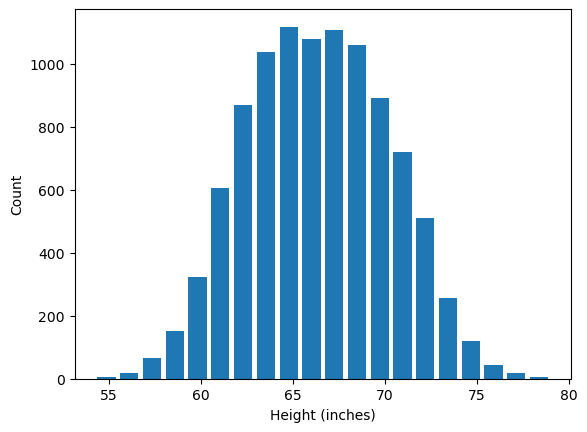

In [16]:
plt.hist(df.height, bins=20, rwidth=0.8)
plt.xlabel('Height (inches)')
plt.ylabel('Count')
plt.show()

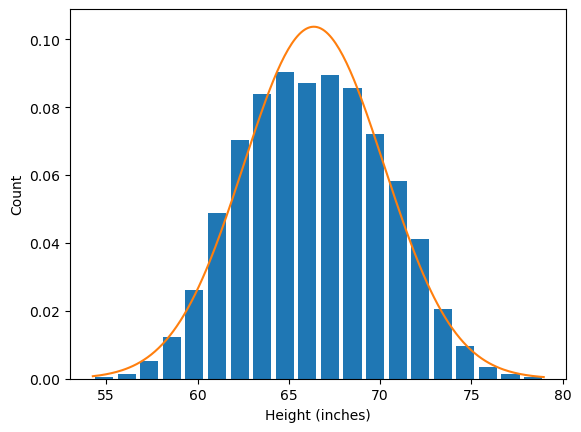

In [18]:
from scipy.stats import norm
import numpy as np
plt.hist(df.height, bins=20, rwidth=0.8, density=True)
plt.xlabel('Height (inches)')
plt.ylabel('Count')

rng = np.arange(df.height.min(), df.height.max(), 0.1)
plt.plot(rng, norm.pdf(rng,df.height.mean(),df.height.std()))

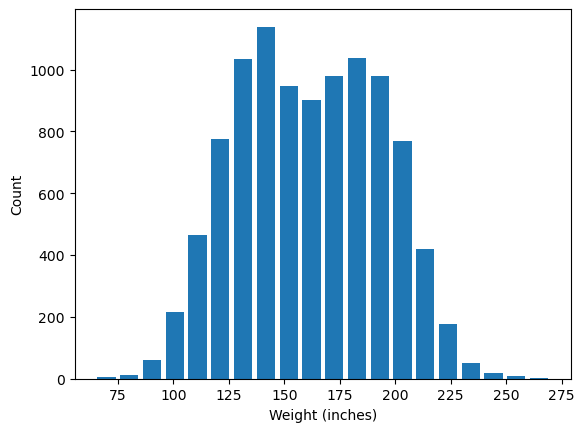

In [19]:
plt.hist(df.weight, bins=20, rwidth=0.8)
plt.xlabel('Weight (inches)')
plt.ylabel('Count')
plt.show()

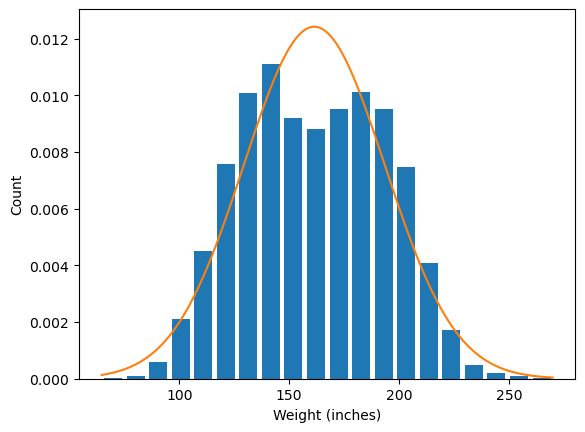

In [20]:
from scipy.stats import norm
import numpy as np
plt.hist(df.weight, bins=20, rwidth=0.8, density=True)
plt.xlabel('Weight (inches)')
plt.ylabel('Count')

rng = np.arange(df.weight.min(), df.weight.max(), 0.1)
plt.plot(rng, norm.pdf(rng,df.weight.mean(),df.weight.std()))

In [22]:
q1 = df.height.quantile(0.25)
q3 = df.height.quantile(0.75)
q1, q3

(63.505620481218955, 69.1742617268347)

In [23]:
IQR = q3 - q1
IQR

5.668641245615746

In [24]:
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
lower_limit, upper_limit

(55.00265861279534, 77.67722359525831)

In [25]:
df2 = df[(df.height>lower_limit)&(df.height<upper_limit)]
df2

,gender,height,weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [26]:
df.shape

(10000, 3)

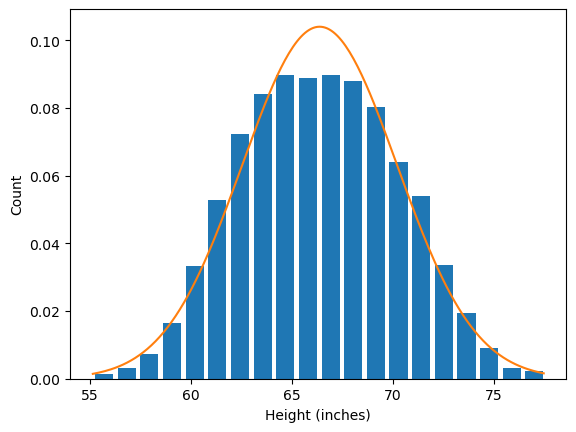

In [27]:
from scipy.stats import norm
import numpy as np
plt.hist(df2.height, bins=20, rwidth=0.8, density=True)
plt.xlabel('Height (inches)')
plt.ylabel('Count')

rng = np.arange(df2.height.min(), df2.height.max(), 0.1)
plt.plot(rng, norm.pdf(rng,df2.height.mean(),df2.height.std()))

In [28]:
Q1 = df.weight.quantile(0.25)
Q3 = df.weight.quantile(0.75)
Q1, Q3

(135.8180513055015, 187.16952486868348)

In [29]:
iqr = q3 - q1
iqr

5.668641245615746

In [30]:
lower_limit = Q1 - 1.5*iqr
upper_limit = Q3 + 1.5*iqr
lower_limit, upper_limit

(127.31508943707789, 195.6724867371071)

In [32]:
df3 = df2[(df2.weight>lower_limit)&(df2.weight<upper_limit)]
df3

,gender,height,weight
1,Male,68.781904,162.310473
5,Male,67.253016,152.212156
6,Male,68.785081,183.927889
7,Male,68.348516,167.971110
8,Male,67.018950,175.929440
...,...,...,...
9992,Female,62.077832,138.691680
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319


In [33]:
df.shape

(10000, 3)

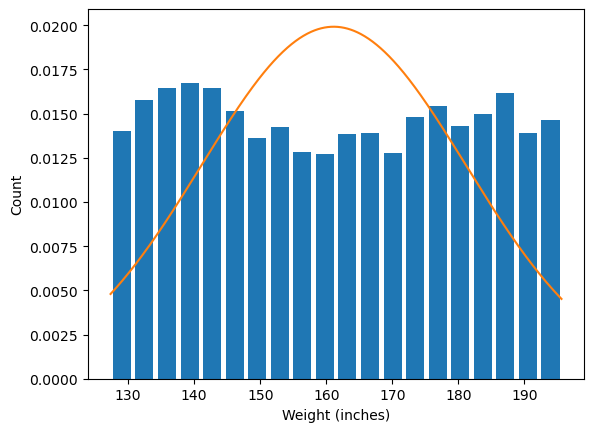

In [34]:
from scipy.stats import norm
import numpy as np
plt.hist(df3.weight, bins=20, rwidth=0.8, density=True)
plt.xlabel('Weight (inches)')
plt.ylabel('Count')

rng = np.arange(df3.weight.min(), df3.weight.max(), 0.1)
plt.plot(rng, norm.pdf(rng,df3.weight.mean(),df3.weight.std()))